In [14]:
# Reload modules automatically
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
import cma
import numpy as np
from numbers import Real
from transformers import CLIPProcessor, CLIPModel
import torch
from sentence_transformers import SentenceTransformer
from PIL import Image
import random
import requests
from io import BytesIO
import time
from matplotlib import cm
import matplotlib.pyplot as plt
from tqdm import tqdm
from os import path
from sentence_transformers import CrossEncoder
import os
from IPython.display import display, clear_output


# Utils imports
from utils.rasterize import *
from utils.clipemb import CLIP_emb_from_IMG, CLIP_emb_from_TEXT
from utils.load import get_segment_imgs, get_primitive_imgs
from utils.cma import clip_sol



DEVICE='cuda' if torch.cuda.is_available() else 'cpu'

WIDTH = 300
HEIGHT = 300

CONTENT_DIR = './data'
RESULTS_DIR = path.join(CONTENT_DIR, 'results')
SEGMENT_DIR = path.join(CONTENT_DIR, 'segment_img')
RW_PRIMITIVES_DIR = path.join(CONTENT_DIR, 'rw_primitives')
PRIMITIVE_DIR = path.join(CONTENT_DIR, 'primitives')

SEGMENT_IMGS = get_segment_imgs(SEGMENT_DIR, (WIDTH, HEIGHT))
#RW_PRIMITIVES_IMGS = get_segment_imgs(RW_PRIMITIVES_DIR, (WIDTH, HEIGHT))
PRIMITIVE_IMGS = get_primitive_imgs(CONTENT_DIR, (WIDTH, HEIGHT))

In [20]:
prompt_text = 'the statue of liberty'
prompt_text = 'a person with a yellow jacket holding a big red umbrella'
prompt_embedding = CLIP_emb_from_TEXT(prompt_text)
prompt_embedding = CLIP_emb_from_IMG(SEGMENT_IMGS[prompt_text]['original'])

#primitives_selected_names = list(RW_PRIMITIVES_IMGS[prompt_text].keys())
#if 'original' in primitives_selected_names:
#    primitives_selected_names.remove('original') # This is the original image aka the prompt

primitives_selected_names = list(SEGMENT_IMGS[prompt_text].keys())
if 'original' in primitives_selected_names:
    primitives_selected_names.remove('original') # This is the original image aka the prompt

primitives_selected = [SEGMENT_IMGS[prompt_text][name] for name in primitives_selected_names]

# Initial solution
predictN = 5
N = len(primitives_selected)


cuda


KeyError: 'a person with a yellow jacket holding a big red umbrella'

In [21]:
def loop(es, primitives_selected, max_val, prev_positions):
  report_interval = 10
  i = 0
  while not es.stop():
      a = time.time()
      solutions = es.ask()

      rasterized_imgs = []

      b = time.time()
      for it, solution in enumerate(solutions):
        # Reshape (one for each primitive)
        solution = solution.reshape(-1, predictN)
        # Special clip for scale
        
        solution = clip_sol(solution, max_val)

        # The  previous positions
        if prev_positions is not None:
          solution = np.vstack([prev_positions, solution.squeeze()])

        img = rasterize_shapes_2(primitives_selected, solution, (WIDTH, HEIGHT))
        rasterized_imgs.append(Image.alpha_composite(
                                  #Image.new("RGBA", img.size, (54, 108, 176, 255)),  # White background
                                  Image.new("RGBA", img.size, (255, 255, 255, 255)),  # White background
                                  img
                              ).convert("RGB"))

      rasterized_imgs = np.stack(rasterized_imgs, axis=0) # (population_size, 300, 300, 4)
      rasterized_imgs = torch.tensor(rasterized_imgs).permute(0, 3, 1, 2).to(DEVICE)
      c = time.time()
      rasterized_emb = CLIP_emb_from_IMG(rasterized_imgs) # (population_size, 512)

      losses = torch.nn.functional.cosine_similarity(rasterized_emb, prompt_embedding, dim=1)

      t = time.time()
      print(f"ALL: {b-a}")
      print(f"SOL: {c-b}")
      print(f"EMB: {t-c}")
      print(f'best loss = {losses.max()}')
      print(f'avg loss = {np.average(losses.cpu())}')
      if i % 1 == 0:
        print(f'loss migliore = {losses.max()}')
        best = solutions[losses.argmax()]
        img = rasterized_imgs[losses.argmax()].cpu().numpy()
        img = np.transpose(img, (1,2,0))
        img_pil = Image.fromarray(img.astype('uint8'), 'RGB')
        #img_pil.save(path.join(RESULTS_DIR, f'img{i}.png'))
        clear_output(wait=True)  # Clear previous output
        display(img_pil)         # Display the new image

      print(losses.max())
      # Minus because wpochettee want to maximize the similarity
      es.tell(solutions, [-l.item() for l in losses])
      i += 1
  return clip_sol(es.best.x.reshape(-1, predictN), max_val)
    


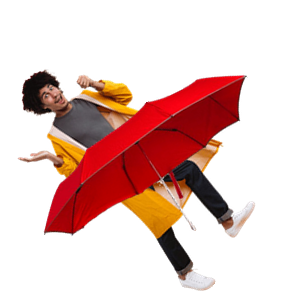

tensor(0.3716, device='cuda:0')


In [ ]:
# Alternate between the shapes, one moves the rest are fixed
sigma = 0.1
maxiter = 50
popsize = 256
max_val = 0.5

sel_shapes = []
prev_positios = None

for shape in primitives_selected:
    sel_shapes.append(shape)

    x0 = np.ones((1, 5)) * 0.5
    # No rotation
    x0[0, 3] = 0

    es = cma.CMAEvolutionStrategy(x0.flatten(), sigma, {
        "maxiter": maxiter,
        "popsize": popsize,
        "bounds": [-max_val, max_val],
        })

    prev_best = loop(es, sel_shapes, max_val, prev_positios)

    if prev_positios is None:
        prev_positios = prev_best.squeeze()
        prev_positios[-1] = 1 / 2
    else:
        prev_positios = np.vstack([prev_positios, prev_best.squeeze()])

In [23]:
display(SEGMENT_IMGS[prompt_text]['original'])

KeyError: 'a person with a yellow jacket holding a big red umbrella'